In [15]:
import pymc as pm
from dataloader import samlet_df
import numpy as np
import arviz as az
from scipy.stats import gaussian_kde
from scipy.stats import weibull_min
import matplotlib.pyplot as plt

$p(kass) = a\cdot dage + b\cdot vask$

# Weibull model

In [7]:
#finder rækker hvor dage=0 eller vask=0 
mask = (samlet_df['Dage i cirkulation'] == 0) | (samlet_df['Total antal vask'] == 0)
print(mask.sum(), 'ud af', len(samlet_df))

#fjerner dem fra df
samlet_df_filtered = samlet_df[~mask]

#sample en delmængde af dataen mens modellen udvikles
samlet_df_sample = samlet_df_filtered.sample(n=1000, random_state = 42)

21535 ud af 247265


Formålet ved det følgende er at lave en model der estimerer levetiden for et stykke tøj indtil kassation. 

Vi bruger en Bayesiansk tilgang da det giver os mulighed for at inkode forhåndsviden om parametrene via priors, og dermed 
opnå mere robuste estimater end maximum likelihood estimation.

Vi vælger en Weibull survival model da vores data udelukkende består af kasserede tøjstykker, dvs kendte hændelsestidspunkter (kassation). 
Weibull er velegnet til dette da den eksplicit modellerer tid-til-hændelse og kan fange stigende risiko over tid via shape-parameteren alpha.

En Weibull model har form
$$dage_i \sim Weibull(\alpha,\beta)$$
Hvor $\alpha$ styrer om risikoen for kassation stiger ($\alpha>1$), er konstant ($\alpha =1$) eller falder ($\alpha<1$) over tid. $\beta$ styrer den typiske levetid. Som prior for $\alpha$ valgte vi
$$\alpha \sim Gamma(\mu_{prior},\sigma_{prior})$$
da Gammafordelingen garanterer positiv $\alpha$-værdi, samt er der mulighed for centrering omkring en bestemt værdi gennem $\mu_{prior}$ og $\sigma_{prior}$. Vores $\mu_{prior}$ estimeres ved at fitte en weibull til vores variabel "Dage i cirkulation", mens $\sigma_{prior}$ vælges manuelt som et mål for usikkerhed på $\alpha$-estimated. 

Vores $\beta$ har vi valgt at modellere som
$$\beta_i = e^{intercept+a*vask_{norm,i}}$$
da eksponentialfunktionen garanterer positive værdier. Vi har valgt at normalisere variablen "Total antal vaske" til vask\_norm for at undgå numerisk ustabilitet, da store vask-værdier fører til ekstremt høje $\beta$-værdier, der kan dominere den afhængige variabel i vores model. Vi introducerede intercept 
$$intercept \sim Normal(\mu_{prior},\sigma_{prior})$$
for at sikre at $\beta$-værdierne er i samme størrelsesorden som "Dage i cirkulation". Til dette brugte vi normalfordelingen, da  intercept kan antage både positive og negative værdier, og derfor er den oplagte fordeling at bruge som prior. $\mu_{prior}$ bestemmes ud fra logaritmen af vores beta-estimat fra Weibull fittet, for at garantere korrekt størrelsesorden. 
Til sidst har vi "a" der styrer forklaringskraften af vask på forventet levetid $\beta$ og den prior har vi defineret er
$$a\sim HalfNormal(\sigma_prior)$$
Da a skal have positiv værdi og vi skal kunne styre usikkerheden omkring estimatet med $\sigma$, der vælges af os. Dermed er Half-normalfordeling, en normalfordeling afskåret i 0, den oplagte prior.

Note to self:
Den følgende Weibull model er estimeret med et sample af det fulde datasæt for effektivitetens skyld ved ændringer af variable. Modellen er endnu ikke kørt på det fulde datasæt.

In [ ]:
# Weibull fit på fulde datasæt. Kommenteret ud indtil videre.

# alpha_est, _, beta_est = weibull_min.fit(samlet_df_filtered['Dage i cirkulation'], floc=0)
# print(alpha_est, beta_est)

1.2859154024089614 1264.9788864156196


Følgende kode laver weibull fitted

In [8]:
alpha_est, _, beta_est = weibull_min.fit(samlet_df_sample['Dage i cirkulation'], floc=0)
print(alpha_est, beta_est)

1.2843340360109643 1273.7289615170548


Vi vælger $intercept = \ln(\beta_{est})$, så $\beta \approx \beta_{est} \approx 1265$ ved gennemsnitlig vask ($vask_{norm} = 0$).

In [9]:
mean_dage = samlet_df['Dage i cirkulation'].mean()
mean_vask = samlet_df['Total antal vask'].mean()
#normalisering
vask_norm = (samlet_df_sample['Total antal vask'] - mean_vask) / samlet_df_sample['Total antal vask'].std()

with pm.Model() as model:
    #priors
    alpha = pm.Gamma('alpha', mu = alpha_est, sigma=0.5)
    intercept = pm.Normal('intercept', mu=np.log(beta_est), sigma=1)
    a = pm.HalfNormal('a', sigma=1) #halfnormal er normalfordelingen med afskæring i 0. Kun højre side

    #deterministisk funktion af a og observerede data
    beta = pm.math.exp(intercept + a * vask_norm)

    #likelihood
    obs = pm.Weibull('obs', alpha = alpha, beta = beta, observed = samlet_df_sample['Dage i cirkulation'])
    
    #resultat
    trace = pm.sample(draws=500, tune=500, chains=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, intercept, a]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 401 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [10]:
az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,7.081,0.023,7.040,7.126,0.001,0.001,753.0,724.0,1.0
alpha,1.372,0.032,1.312,1.431,0.001,0.001,889.0,734.0,1.0
a,0.304,0.025,0.260,0.351,0.001,0.001,1239.0,692.0,1.0


Vi får en alpha-værdi > 1, hvilket stemmer overens med forventingen om at kassationsrisiko stiger over tid.

Vi plotter for at visuallere vores Weibull model sammen med vores observeret data.

Sampling: [obs]


Output()

<Axes: xlabel='obs'>

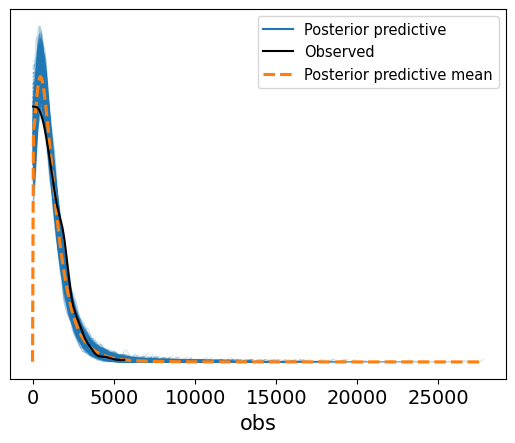

In [11]:
with model:
    ppc = pm.sample_posterior_predictive(trace)

az.plot_ppc(ppc)

Det ligner et rimelig godt fit til forklaring af levetiden af et stykke tøj. ISÆR fordi dette resultat fremkommer af sample-dataen, så ved den fulde model estimation med hele datasættet forventer vi et endnu bedre fit.

(1000, 1000)


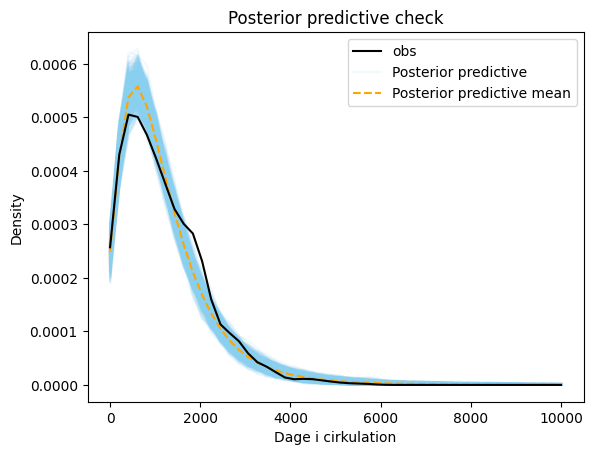

In [38]:
x = np.linspace(0, 10000)
kde_obs = gaussian_kde(samlet_df_sample['Dage i cirkulation'])
y = kde_obs(x)
plt.plot(x, y, color = 'black', label = "obs", zorder = 3)
samples = ppc.posterior_predictive['obs'].values.reshape(-1,1000)
print(samples.shape)
kde_values = []
for i, sample in enumerate(samples):
    kde_sim = gaussian_kde(sample)
    kde_values.append(kde_sim(x))
    label = "Posterior predictive" if i == 0 else None
    plt.plot(x, kde_sim(x), color= '#89CFF0', alpha = 0.1, label = label, zorder = 1)

mean_kde = np.mean(kde_values, axis=0)
plt.plot(x, mean_kde, color='orange', linestyle='--', label = "Posterior predictive mean", zorder = 2)
plt.title("Posterior predictive check")
plt.ylabel("Density")
plt.xlabel("Dage i cirkulation")
plt.legend()


# Poisson model (VIRKER IKKE)

Valgte eksponential fordelingen for a og b, fordi $a,b>0$ og flere dage i cirkulation og flere antal vaske øger slid på tøjet.

Så for at vælge de korrekte parametre finder vi middelværdien af dage og vaske i dataen

In [2]:
#mean af eksponential
mean_dage = samlet_df['Dage i cirkulation'].mean()
mean_vask = samlet_df['Total antal vask'].mean()

mean_dage, mean_vask

(np.float64(1092.732440903484), np.float64(31.01294966938305))

In [3]:
mean_dage/mean_vask

np.float64(35.2347149352989)

Det ses at disse means er på forskellige skalaer, 1092:31. Dette tager vi højde for, så både dage og vask bidrager lige meget til p(kass). 

Eftersom middelværdien for eksponentialfordelingen er $mean=\frac{1}{λ}$, gælder det at $\lambda=\frac{1}{mean}$. Vi vælger λ ud fra data dermed:

$$\lambda_a=mean\_dage,\quad\lambda_b=mean\_vask$$

Fordi så er $a⋅mean\_dage≈b⋅mean\_vask≈1$ så begge variable bidrager lige meget til p(kass).

In [4]:
b = 1 /mean_vask
a = (b*mean_vask)/mean_dage
a, b

(np.float64(0.0009151371027048379), np.float64(0.032244594940520316))

Tjekker at ovenstående ligning holder

In [5]:
np.isclose(a*mean_dage, b*mean_vask)

np.True_

kan dermed opstille priors:
$$a \sim \exp(\lambda_a = mean\_dage), \quad b\sim \exp(\lambda_b = mean\_vask)$$
Vi vælger Poisson som likelihood fordi vi modellerer kassering som en rate-proces — tøj akkumulerer slid over tid via dage og vaske indtil kassering indtræffer. Alle observationer er kasserede (event = 1), så vi sætter observed = 1 for alle rækker. Modellen lærer a og b så λ = a·dage + b·vask ≈ 1, hvilket svarer til at kasseringsraten passer med de observerede data.

Dermed bliver modellen

In [6]:
#rækker hvor dage=0 eller vask=0 giver lam=0, hvilket er ugyldigt for Poisson
mask = (samlet_df['Dage i cirkulation'] == 0) | (samlet_df['Total antal vask'] == 0)
print(mask.sum(), 'ud af', len(samlet_df))

#fjerner dem fra df
samlet_df_filtered = samlet_df[~mask]

#sample en delmængde af dataen mens modellen udvikles
samlet_df_sample = samlet_df_filtered.sample(n=1000, random_state = 42)

21535 ud af 247265


In [7]:
with pm.Model() as model:
    #priors for a og b
    a = pm.Exponential('a', lam = mean_dage)
    b = pm.Exponential('b', lam= mean_vask)
    
    #lineær kombination hvor det rigtige data bruges
    lam = a * samlet_df_sample['Dage i cirkulation'] + b * samlet_df_sample['Total antal vask']

    # likelihood funktionen
    obs = pm.Poisson('obs', mu = lam, observed = np.ones_like(samlet_df_sample['Dage i cirkulation']))

    #resultatet
    trace = pm.sample(draws=500, tune=500, chains=2)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [a, b]


Output()

Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 288 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [8]:

az.summary(trace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.001,0.000,0.001,0.001,0.0,0.0,272.0,485.0,1.00
b,0.005,0.001,0.003,0.007,0.0,0.0,246.0,397.0,1.01


In [10]:
a_posterior = 0.001 
b_posterior = 0.005

Ved så at se på de to led i p(kass) kan jeg se deres bidrag til kassation.

In [11]:
bidrag_dage = a_posterior * mean_dage
bidrag_vask = b_posterior * mean_vask
bidrag_dage, bidrag_vask

(np.float64(1.0927324409034842), np.float64(0.15506474834691525))

Da bidraget for dage er meget større end for vask betyder det, at tid i cirkulation er en stærkere driver for kassering end antal vaske

Simulerer nu nyt data ud fra min posterior

pm.sample_posterior_predictive(trace):

- Tager mine samplede værdier af a og b fra trace og bruger dem til at simulere nye observationer via min model. For hvert sample af (a, b) beregnes $\lambda = a\cdot dage + b\cdot vask$ og der samples fra Poisson($\lambda$).
Resultatet er et datasæt af simulerede kasseringer.

Posterior predictive check bruges til at validere modellen ved at sammenligne simulerede data med observerede data. Vi sampler fra posterioren for at afspejle usikkerheden på a og b, frem for blot at bruge deres middelværdier. 

In [12]:
with model:
    ppc = pm.sample_posterior_predictive(trace)

#henter de simulerede værdier og beregner mean og std. afvigelse
print(ppc.posterior_predictive['obs'].values.mean())
print(ppc.posterior_predictive['obs'].values.std()) 

Sampling: [obs]


Output()

1.001447
1.2513292557081048


<Axes: xlabel='obs'>

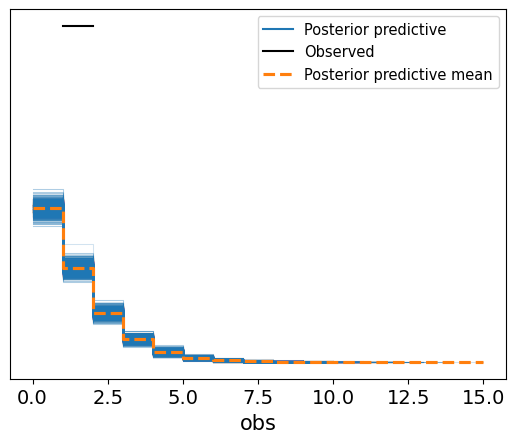

In [15]:
az.plot_ppc(ppc)